In [1]:
%load_ext autoreload
%autoreload 2

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

XGBoost is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
# Define some utilities functions
def configure_notebook(seed: int = 10301, float_precision: int = 3, max_columns: int = 15, max_rows: int = 25) -> int:
    """
    Configure notebook settings:
      - Disables warnings for cleaner output.
      - Sets pandas display options for better table formatting.
      - Returns a seed value for reproducibility.
    
    Parameters:
      seed (int): Random seed (default 548).
      float_precision (int): Number of decimal places for floats (default 3).
      max_columns (int): Maximum number of columns to display (default 15).
      max_rows (int): Maximum number of rows to display (default 25).

    Returns:
      int: The provided seed.
    """
    # Disable all warnings
    warnings.filterwarnings('ignore')
    
    # Set pandas display options for nicer output
    pd.options.display.float_format = f'{{:,.{float_precision}f}}'.format
    pd.set_option('display.max_columns', max_columns)
    pd.set_option('display.max_rows', max_rows)

    # Set seeds for reproducibility in numpy and the standard random module
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    return seed

def running_in_kaggle() -> bool:
    """
    Heuristics that are true in Kaggle notebooks:
    - Special directories exist (/kaggle/input, /kaggle/working)
    - Env var KAGGLE_KERNEL_RUN_TYPE is set
    - The kaggle_secrets module is available
    """
    try:
        if os.path.isdir('/kaggle/input') and os.path.isdir('/kaggle/working'):
            return True
        if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
            return True
        import kaggle_secrets  # noqa: F401  (only exists in Kaggle)
        return True
    except Exception:
        return False

In [4]:
# Apply configuration and set random seeds for reproducibility
seed = configure_notebook(max_columns = None, max_rows = None)

TARGET = 'diagnosed_diabetes'
USE_GPU = True
PERFORM_OPTUNA_TUNING = True

## Read and Examine the Training Dataset

In [5]:
DATA_DIR = Path('/kaggle/input/playground-series-s5e12') if running_in_kaggle() else Path('data')

training_df = pd.read_csv(DATA_DIR / 'train.csv')
print(training_df.head(5))

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0               0.930 

## Read and Examine the Test Dataset

In [6]:
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print(test_df.head(5))

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500               

## Feature Engineering

In [7]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'interactions',
    'ratios',
    'log',
    'polynomials',
    'one_hot_encoding'
]

In [8]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

print('Using optimal features derived from an earlier run.')
optimal_cols = pd.Index([
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'bmi',
    'waist_to_hip_ratio',
    'systolic_bp',
    'heart_rate',
    'cholesterol_total',
    'hdl_cholesterol',
    'ldl_cholesterol',
    'triglycerides',
    'family_history_diabetes',
    'cardiovascular_history',
    'non_hdl_cholesterol', 
    'age_bmi_interaction',
    'sedentary_ratio',
    'cholesterol_risk_ratio',
    'whr_bmi_product',
    'triglycerides_log',
    'age_sq',
    'bmi_sq',
    'ethnicity_Other'
])

X_optimal = X_full[optimal_cols]
X_test_optimal = X_test[optimal_cols]

X = X_optimal.drop(TARGET, axis=1, errors='ignore')

print(f"Old Feature Count: {training_df.shape[1] - 1}")
print(f"New Feature Count: {X.shape[1]}")
X.head()

Performing initial feature engineering.
Using optimal features derived from an earlier run.
Old Feature Count: 25
New Feature Count: 22


,age,physical_activity_minutes_per_week,diet_score,bmi,waist_to_hip_ratio,systolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,cardiovascular_history,non_hdl_cholesterol,age_bmi_interaction,sedentary_ratio,cholesterol_risk_ratio,whr_bmi_product,triglycerides_log,age_sq,bmi_sq,ethnicity_Other
0,31,45,7.700,33.400,0.930,112,62,199,58,114,102,0,0,141,"1,035.400",0.133,3.431,31.062,4.635,961,"1,115.560",0
1,50,73,5.700,23.800,0.830,120,71,199,50,121,124,0,0,149,"1,190.000",0.078,3.980,19.754,4.828,2500,566.440,0
2,32,158,8.500,24.100,0.830,95,73,188,59,114,108,0,0,129,771.200,0.057,3.186,20.003,4.691,1024,580.810,0
3,54,77,4.600,26.600,0.830,121,74,182,54,85,123,0,0,128,"1,436.400",0.118,3.370,22.078,4.820,2916,707.560,0
4,54,55,5.700,28.800,0.900,108,85,206,49,131,124,0,0,157,"1,555.200",0.091,4.204,25.920,4.828,2916,829.440,0


## Optuna Training and Recursive Feature Elimination

This section optionally runs an Optuna trial to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

If Optuna Tuning was run, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.

In [9]:
n_jobs = 1 if USE_GPU else -1

def objective(trial):
    
    # Suggest Parameters
    param = {
        'n_estimators': 3000,              # Give it room to run, let early stopping cut it
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),  # L1 Reg
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # L2 Reg
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        
        # Boilerplate
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'random_state': seed,
        'early_stopping_rounds': 50,
        'n_jobs': n_jobs
    }

    # Fast CV (3 Folds is enough for tuning)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Create XGBoost internal DMatrix for efficiency
        # (Optional, but good practice. passing dataframes directly is fine too)
        model = xgb.XGBClassifier(**param)
        
        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=False
        )
        
        # Predict
        preds = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, preds)
        scores.append(score)

    return np.mean(scores)

if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='xgb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=40, show_progress_bar=True)

    print("Best Params:", study.best_params)
    print("Best AUC:", study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.09917530943828724,
        'max_depth': 3,
        'subsample': 0.7807183204858182,
        'colsample_bytree': 0.567694195924514,
        'min_child_weight': 2,
        'reg_alpha': 3.929531370823257,
        'reg_lambda': 0.0010695500594712366,
        'gamma': 1.62730523190185
    }

[I 2025-12-04 11:47:58,537] A new study created in memory with name: xgb_diabetes_prediction_optuna


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-04 11:48:18,299] Trial 0 finished with value: 0.7239233524598272 and parameters: {'learning_rate': 0.04616452909472715, 'max_depth': 4, 'subsample': 0.9108572525117714, 'colsample_bytree': 0.838563141577915, 'min_child_weight': 4, 'reg_alpha': 1.1448758024911176, 'reg_lambda': 9.746437376742904, 'gamma': 3.32399404027333}. Best is trial 0 with value: 0.7239233524598272.
[I 2025-12-04 11:48:45,747] Trial 1 finished with value: 0.725068412445698 and parameters: {'learning_rate': 0.023240835060145786, 'max_depth': 6, 'subsample': 0.7686859489804779, 'colsample_bytree': 0.7327861351420975, 'min_child_weight': 6, 'reg_alpha': 0.6359277403240902, 'reg_lambda': 0.0011879510585606102, 'gamma': 3.9534900068178613}. Best is trial 1 with value: 0.725068412445698.
[I 2025-12-04 11:49:05,506] Trial 2 finished with value: 0.7248530781211322 and parameters: {'learning_rate': 0.03372748057380603, 'max_depth': 6, 'subsample': 0.7310621210013319, 'colsample_bytree': 0.6110219551590523, 'min_c

Running Recursive Feature Elimination (this may take 2-3 minutes)...
Optimal number of features: 22


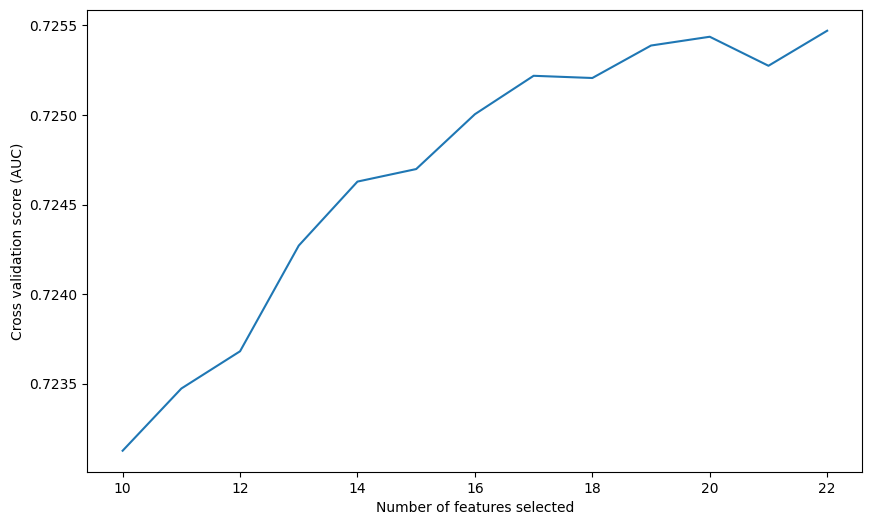


Optimal Features:
['age', 'physical_activity_minutes_per_week', 'diet_score', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'cardiovascular_history', 'non_hdl_cholesterol', 'age_bmi_interaction', 'sedentary_ratio', 'cholesterol_risk_ratio', 'whr_bmi_product', 'triglycerides_log', 'age_sq', 'bmi_sq', 'ethnicity_Other']


In [10]:
if PERFORM_OPTUNA_TUNING:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")
    
    # Create a copy so we don't mess up the main config
    rfe_params = best_params.copy()
    
    # Remove early_stopping_rounds
    if 'early_stopping_rounds' in rfe_params:
        del rfe_params['early_stopping_rounds']
    
    # Speed up RFE by limiting trees (3000 is overkill for feature ranking)
    rfe_params['n_estimators'] = 1000
    
    # 'gpu_hist' is removed. Now we use 'hist' + device='cuda'
    rfe_params['tree_method'] = 'hist'
    if USE_GPU:
        rfe_params['device'] = 'cuda'
    else:
        rfe_params['device'] = 'cpu'
    
    # Setup Model with Best Params
    # We use the exact same params that found the signal in the noise
    clf = xgb.XGBClassifier(**rfe_params)
    
    # Initialize RFECV
    # step=1: remove 1 feature at a time (most precise)
    # min_features_to_select=10: Don't go below 10 features
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring='roc_auc',
        min_features_to_select=10,
        n_jobs=n_jobs,
        verbose=0
    )
    
    print("Running Recursive Feature Elimination (this may take 2-3 minutes)...")
    rfecv.fit(X, y)
    
    # Results
    print(f"Optimal number of features: {rfecv.n_features_}")
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel("Number of features selected")
    plt.ylabel("Cross validation score (AUC)")
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X.columns[rfecv.support_]
else:
    print('Using optimal features derived from an earlier run.')
    optimal_cols = pd.Index([
        'age',
        'physical_activity_minutes_per_week',
        'diet_score',
        'bmi',
        'waist_to_hip_ratio',
        'systolic_bp',
        'heart_rate',
        'cholesterol_total',
        'hdl_cholesterol',
        'ldl_cholesterol',
        'triglycerides',
        'family_history_diabetes',
        'cardiovascular_history',
        'non_hdl_cholesterol', 
        'age_bmi_interaction',
        'sedentary_ratio',
        'cholesterol_risk_ratio',
        'whr_bmi_product',
        'triglycerides_log',
        'age_sq',
        'bmi_sq',
        'ethnicity_Other'
    ])
    
print("\nOptimal Features:")
print(optimal_cols.tolist())

## Model Training

In [11]:
# Cross-Validation Training Loop

xgb_tuned_params = {
    **best_params,
    'n_estimators': 2000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': n_jobs,
    'random_state': seed,
    'early_stopping_rounds': 50,
    'tree_method': 'gpu_hist' if USE_GPU else None,
}

# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]
X_test_rfe = X_test[optimal_cols]

# Arrays to store results
oof_preds = np.zeros(len(X))     # Out-of-Fold predictions (for blending later)
test_preds = np.zeros(len(test_df)) # Average test predictions

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f"\nStarting XGBoost Training ({n_folds} Folds)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_rfe, y)):
    X_train, y_train = X_rfe.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X_rfe.iloc[val_idx], y.iloc[val_idx]
    
    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = xgb.XGBClassifier(**xgb_tuned_params)
    
    # Train Model
    # The pipeline will call feature_factory.fit_transform(X_train)
    # and then pass that result to xgb.fit()
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100
    )
    
    # Predict Validation Set
    # [:, 1] grabs the probability of class 1 (Diabetes)
    val_probs = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Score
    score = roc_auc_score(y_val, val_probs)
    print(f"Fold {fold+1} AUC: {score:.5f} (Best Iteration: {model.best_iteration})")
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict_proba(X_test_rfe)[:, 1]
    test_preds += test_probs / n_folds

# Evaluation

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {overall_auc:.5f}")


Starting XGBoost Training (5 Folds)...
[0]	validation_0-auc:0.66353
[100]	validation_0-auc:0.70779
[200]	validation_0-auc:0.71515
[300]	validation_0-auc:0.71925
[400]	validation_0-auc:0.72158
[500]	validation_0-auc:0.72320
[600]	validation_0-auc:0.72441
[700]	validation_0-auc:0.72497
[800]	validation_0-auc:0.72541
[900]	validation_0-auc:0.72571
[1000]	validation_0-auc:0.72601
[1100]	validation_0-auc:0.72615
[1200]	validation_0-auc:0.72635
[1300]	validation_0-auc:0.72645
[1400]	validation_0-auc:0.72654
[1442]	validation_0-auc:0.72650
Fold 1 AUC: 0.72654 (Best Iteration: 1393)
[0]	validation_0-auc:0.66432
[100]	validation_0-auc:0.70679
[200]	validation_0-auc:0.71486
[300]	validation_0-auc:0.71828
[400]	validation_0-auc:0.72094
[500]	validation_0-auc:0.72277
[600]	validation_0-auc:0.72394
[700]	validation_0-auc:0.72457
[800]	validation_0-auc:0.72499
[900]	validation_0-auc:0.72532
[1000]	validation_0-auc:0.72558
[1100]	validation_0-auc:0.72586
[1200]	validation_0-auc:0.72608
[1300]	valida

## Analyze feature importance

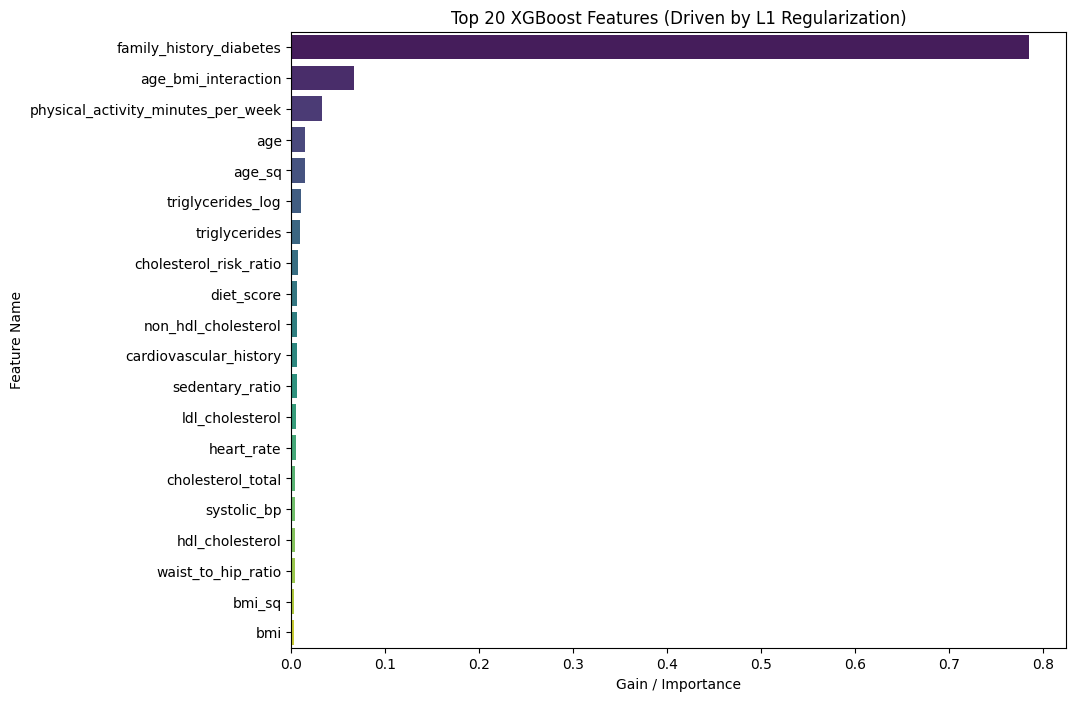

Total Features: 22
Features with > 0 Importance: 22
Features with 0 Importance (Pruned): 0


In [12]:
# Extract Importances
# 'model' is the trained XGBoost classifier from the last fold of your loop
importance = model.feature_importances_
feature_names = X_rfe.columns

# Create a DataFrame & Sort
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot Top 20 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), palette='viridis')
plt.title('Top 20 XGBoost Features (Driven by L1 Regularization)')
plt.xlabel('Gain / Importance')
plt.ylabel('Feature Name')
plt.show()

# Analyze "Dead" Features
zero_imp_features = fi_df[fi_df['Importance'] == 0]
print(f"Total Features: {len(fi_df)}")
print(f"Features with > 0 Importance: {len(fi_df) - len(zero_imp_features)}")
print(f"Features with 0 Importance (Pruned): {len(zero_imp_features)}")

if len(zero_imp_features) > 0:
    print("\nExamples of Pruned Features:")
    print(zero_imp_features['Feature'].head(10).tolist())

## Prepare Submission

In [13]:
submission_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
submission_df[TARGET] = test_preds
submission_df.head(10)

,id,diagnosed_diabetes
0,700000,0.454
1,700001,0.698
2,700002,0.779
3,700003,0.395
4,700004,0.934
5,700005,0.601
6,700006,0.716
7,700007,0.935
8,700008,0.568
9,700009,0.778


In [14]:
submission_df.to_csv("submission.csv", index=False)
print("Saved: submission.csv")

Saved: submission.csv


## Save OOF and Test Predictions

In [15]:
# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_xgb': oof_preds, 'target': y})
oof_df.to_csv("xgb_oof_preds.csv", index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_xgb': test_preds})
test_pred_df.to_csv("xgb_test_preds.csv", index=False)

print("Saved for Blending: xgb_oof_preds.csv, xgb_test_preds.csv")

Saved for Blending: xgb_oof_preds.csv, xgb_test_preds.csv
